In [2]:
%load_ext autoreload
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Image
import utils as ut

# Note
Most of this notebook was created with reference to the following sources:
- https://www.youtube.com/watch?v=K--1hlv9yv0
- https://github.com/lukepolson/youtube_channel/blob/main/Python%20Metaphysics%20Series/vid14.ipynb

The reference notebook had many simplifications for ease of explanation, and these simplifications were addressed in this notebook. For example, the Hamiltonian and subsequent calculations now accommodated external magnetic fields, the energy calculation through convolution was corrected, and extra calculations of magnetisation and magnetic susceptibility were added.

# Introduction

A system in thermal equilibrium with a temperature bath. Probability $p_\mu$ of being in state $\mu$ with energy $E_\mu$ is

 $$p_\mu = \frac{1}{Z} e^{-\beta E_\mu} $$
 
where $Z = \sum_\mu e^{-\beta E_\mu}$ is the **partition function**. At equilbrium, the following must be true

$$\sum_\nu p_\mu P(\mu \to \nu) = \sum_\nu p_\nu P(\nu \to \mu)$$

where $P(\mu \to \nu)$ is the probability of going from state $\mu$ to $\nu$. For our numerical methods, this is difficult to enforce, but we can make it be true be setting the **detailed balance condition**

$$p_\mu P(\mu \to \nu) =p_\nu P(\nu \to \mu)$$

# Ising Model

The total energy is

$$E_\mu = -J\sum_{<i,j>}\sigma_i \sigma_j - \mu_s B\sum_i\sigma_i$$

where $\sigma_i$ is the spin of a single particle in the lattice (either -1 or 1) and the sum over $<i,j>$ means summing over nearest neighbours for all points in the lattice. Furthermore, $\mu_s$ is the magnetic moment of each spin and $B$ is the external magnetic field strength. Now, satisfying detailed balance

$$\frac{P(\mu \to \nu)}{P(\nu \to \mu)} = \frac{p_\nu}{p_\mu} = e^{-\beta (E_\nu-E_\mu)}$$

# Metropolis Algorithm

**The Idea**: Want to find the equilibrium state $\mu$ in the magnet at a particular temperature $\beta$ (how many $\sigma_i$s are +1 and how many are -1). We'll start with a random lattice of spins, some pointing up and some pointing down, and make it dance around using the equation above until it fixes itself into equilibrium

1. Call the current state $\mu$. 
2. Pick a random particle on the lattice and flip the spin sign. Call the state $\nu$. We want to find the probability that $P(\mu \to \nu)$ that we'll accept this new state
3. * If $E_\nu > E_\mu$ then set $P(\nu \to \mu) = 1$ and thus by the detailed balance equation $P(\mu \to \nu) = e^{-\beta (E_\nu-E_\mu)}$. 
    * if $E_\mu > E_\nu$ then set $P(\mu \to \nu) = 1$. Still satisfies detailed balance!
4. Change to state $\nu$ (i.e. flip the spin of the particle) with the probabilities outlined above. 
5. Go back to step 1. Repeat the whole thing many many times and eventually you'll settle into the equilibrium distribution. 

Thus the only thing that needs to be evaluated is

$$-\beta(E_\nu - E_\mu) = -2\beta \sigma_i\left(J\sum_{k=1}^4 \sigma_k+\mu_s B\right)$$

where $i$ is the spin being flipped and $\sigma_k$ are the four nearest neighbours to that spin (two dimensions). Periodic boundary conditions are used, so every spin has exactly four nearest neighbours.

# Dimensionless approach
To keep the whole simulation in terms of dimensionless quantities, the following conventions are used.

The Hamiltonian is measured in units of $J$,

$$\tilde E = -\sum_{<i,j>}\sigma_i\sigma_j - H \sum_i \sigma_i$$

where $\tilde E = E/J$ and $H=\mu_s B/J$. As a result of this convention, the Metropolis factor becomes

$$e^{-\beta\Delta E} \equiv e^{-\beta J \Delta\tilde E}$$

and the only required computation at each iteration of the Metropolis algorithm is

$$\Delta\tilde E = 2\sigma_i \left(\sum_{k=1}^4 \sigma_k + H\right)$$

where $\Delta\tilde E :=  \left(E_\nu - E_\mu\right)/J$.

# Controlled variables
The variables in this code block can be modified for different results. All other code blocks should not be modified.

In [3]:
L = 40 # number of spins in one side of the square lattice (so total there are N = L^2 spins)
ratio = 0.5 # ratio of positive to negative spins

# hamiltonian parameters
H = 0.0 # H = mu_s * B / J
BJ = 0.8

# metropolis parameters
num_sweeps = 300  # number of monte carlo sweeps = num_sweeps * N monte carlo iterations
save_every = L**2 # save snapshots of the lattice for animation every <save_every> monte carlo iteration

# initial portion of run to discard so only equilibrium states are considered for stats calculations
burn_in_fraction = 0.5 

# Basic execution of Metropolis Monte Carlo algorithm

In [4]:
# generate lattice of random spins
lattice = ut.generate_lattice(L, ratio)

Compute the dimensionless energy $$\tilde E_\mu = -\sum_{<i,j>}\sigma_i \sigma_j - H\sum_i\sigma_i$$
The interaction terms can be efficiently computed using convolutions. 

In [5]:
# compute energy of initial system
energy = ut.get_energy(lattice, H)
print(energy)

8.0


In [6]:
# execute algorithm
N = L**2
steps = N * num_sweeps
final_lattice, spins, energies, frames = ut.metropolis(lattice, steps, BJ, H, energy, save_every)

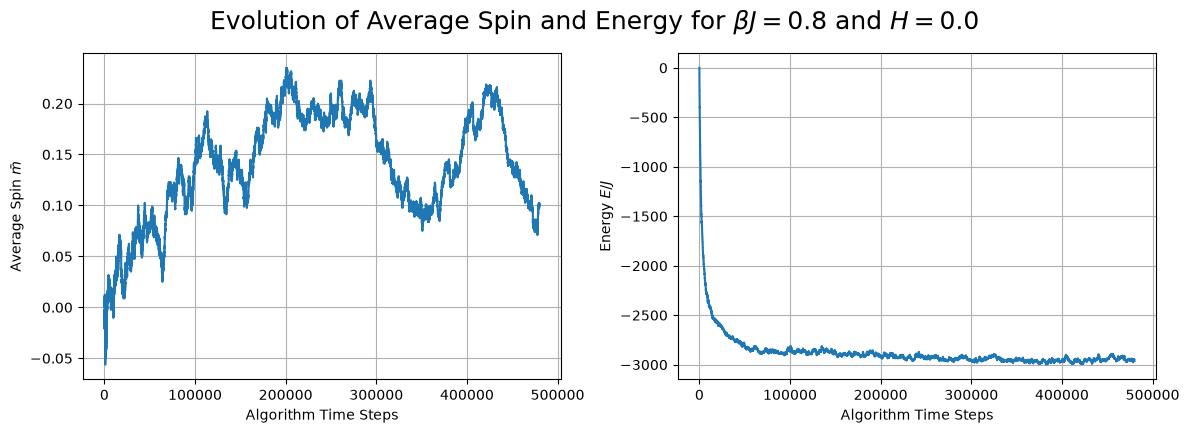

In [7]:
# plot evolution of average spin and energy
fig, axes = plt.subplots(1, 2, figsize=(12,4))
ax = axes[0]
ax.plot(spins/N)
ax.set_xlabel('Algorithm Time Steps')
ax.set_ylabel(r'Average Spin $\bar{m}$')
ax.grid()
ax = axes[1]
ax.plot(energies)
ax.set_xlabel('Algorithm Time Steps')
ax.set_ylabel(r'Energy $E/J$')
ax.grid()
fig.tight_layout()
fig.suptitle(rf'Evolution of Average Spin and Energy for $\beta J={BJ}$ and $H={H}$', y=1.07, size=18)
plt.show()

# Generate animation of evolution
The example in this notebook features an example of a flaw in the Metropolis algorithm. The simulation is more or less stuck with one half as `+1` and the other as `-1`, and the algorithm is not very good at getting out of this situation and stabilising to all `+1` or all `-1`.

In [8]:
ut.make_gif(frames, "ising_evolution.gif", fps=16)

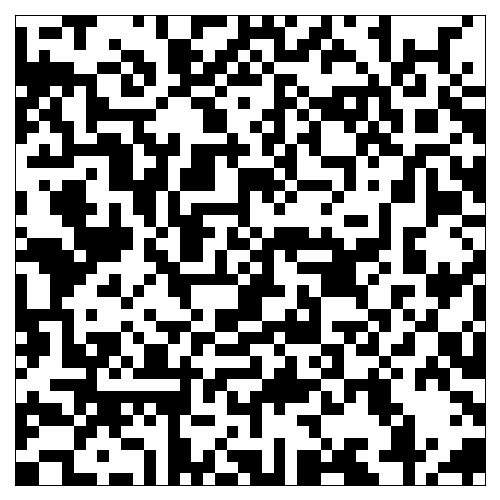

In [12]:
Image(filename="ising_evolution.gif")

# Magnetisation

Magnetisation (average magnetic moment per spin) of a state $r$ is typically defined as

$$m_r = \frac{\mu_s}{N} \sum_i^{N} \sigma_i$$

To preserve our dimensionless approach, we will instead directly measure average spin

$$\tilde m_r = \frac1{N}\sum_i^{N} \sigma_i$$

where $\tilde m_r = m_r / \mu_s$.

In [10]:
start = int(burn_in_fraction * len(spins))

equilibrium_spins = spins[start:]
equilibrium_energies = energies[start:]

m = equilibrium_spins / N
mean_m = np.mean(m)
print(f'Magnetisation is {mean_m:.5f}')

Magnetisation is 0.15193


# Magnetic susceptibility

Magnetic susceptibility is given by

$$\chi := \frac{\partial \braket M}{\partial B}$$

where total magnetisation $M_r := N m_r = N \mu_s \tilde m_r$. Substituting this

$$\chi = N\mu_s \frac{\partial\braket{\tilde m}}{\partial B},$$

using chain rule

$$\frac{\partial\braket{\tilde m}}{\partial B} = \frac{\partial\braket{\tilde m}}{\partial H} \frac{\partial H}{\partial B}$$

and finally using $H = \mu_s B / J$, we obtain

$$\chi = \frac{N\mu_s^2}J \frac{\partial\braket{\tilde m}}{\partial H}$$

where our reduced susceptibility is 

$$\boxed{\tilde\chi := \frac{\partial \braket{\tilde m}}{\partial H}}$$

## blah blah blah

The statistical version is 

$$\chi = \beta \ \text{Var} (M)$$

or, for reduced magnetic susceptibility,

$$\tilde\chi=\beta JN\left(\braket{{\tilde m}^2}-\braket{\tilde m}^2\right).$$

In [11]:
chi = BJ * N * (np.mean(m**2) - np.mean(m)**2)
print(f'Magnetic susceptibility is {chi:.5f}')

Magnetic susceptibility is 2.17206
